In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [2]:
x, y= make_moons(n_samples=150, noise=0.3, random_state=1) #random_state=1 lets us have the same data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=2)

In [3]:
y #do not do regression...classification would be better

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0])

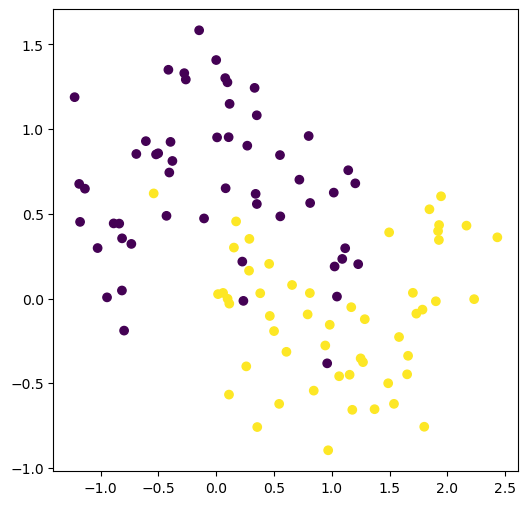

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_train[:,0], x_train[:,1], c=y_train)

In [5]:
from sklearn.neighbors import KNeighborsClassifier as KNN

In [6]:
model = KNN(n_neighbors=6) #pick any value from 1-90 (90 is # of data)

In [7]:
model.fit(x_train, y_train) #give the model training data (first thing we need to do)


KNeighborsClassifier(n_neighbors=6)

In [8]:
model.score(x_test, y_test) #score the model on the test data
#k=6 nearest data has an accuracy of 91%

0.9111111111111111

In [9]:
h=0.02
x_min, x_max = x[:,0].min()-0.5, x[:,0].max()+0.5
y_min, y_max = x[:,1].min()-0.5, x[:,1].max()+0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) #creates 2d grid of x y points

In [10]:

xy_map = np.c_[xx.ravel(), yy.ravel()] #stack the 2d grid into a 1d array

z_values = model.predict(xy_map) #predict the class of each point in the grid

#we need to go back from 1d to 2d
z_map = z_values.reshape(xx.shape) #reshape the 1d array back to 2d

In [11]:
from matplotlib.colors import ListedColormap

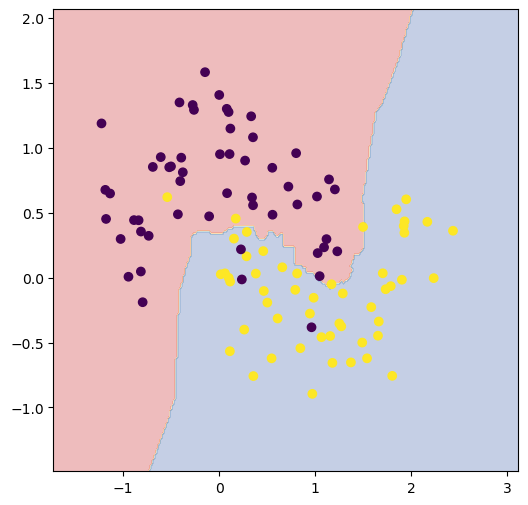

In [12]:
cm = plt.cm.RdYlBu
cm_dim = ListedColormap(["#FFAAAA", "#0000FF"])
fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(xx, yy, z_map, cmap=cm, alpha=0.3) #alpha makes it transparent
ax.scatter(x_train[:,0], x_train[:,1], c=y_train)


In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix #stuff for classification and not regression

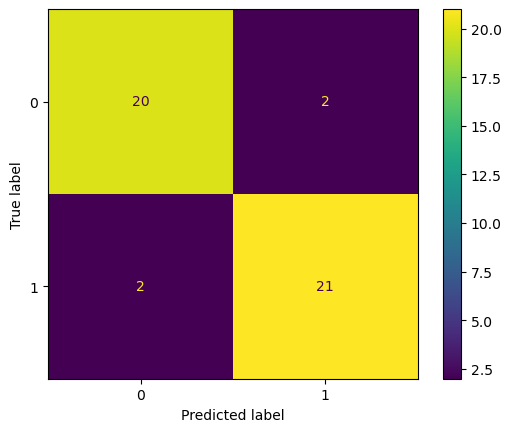

In [14]:
mtx = confusion_matrix(y_test, model.predict(x_test))
ConfusionMatrixDisplay(mtx).plot() #shows incorrectly classified data

SELF LEARNING ACTIVITY ---> CLASSIFICATION ALGORITHM FROM SKLEARN

Valiance tradeoff

In [15]:
#other classification algorithms from sklearn

from sklearn.svm import SVC

In [ ]:
model = SVC(C=1.1) # c controls the margin of the SVM
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8888888888888888

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
model = DecisionTreeClassifier(max_depth=97) # max_dept is the depth of the tree
#changes the number of decisions the tree can make
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8444444444444444

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(n_estimators=100, max_depth=106) # n_estimators is the number of trees
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8666666666666667